In [1]:
import sys
sys.path.append("../")
import numpy as np

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.icp2D_localization_tb import icp2DLocalizationTB
from odometry.localization.icp2D_localization import icp2DLocalization

In [2]:
#setup the datasets
dataset = radnavDS(
    dataset_path="/data/radnav/rad_nav_experiments/wilk_4th_lr_CFAR_7dB_multi_test_5/",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data"
)

#load the map
map_handler = MapHandler(
    maps_folder="/data/radnav/maps",
    map_file="wilkinson.yaml"
)

found 1892 radar samples
found 1892 lidar samples
found 1892 camera samples
found 1892 imu (orientation only) samples
did not find imu (full data) samples
loaded map from /data/radnav/maps/wilkinson.yaml


In [3]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.5,
    icp_best_points_percentile=40,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=4,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6,
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

loaded map with 20750 points
loaded map with 20750 points
icp estimated heading:-0.16613928817009552 deg, pose:[-0.13709706  0.016873  ]


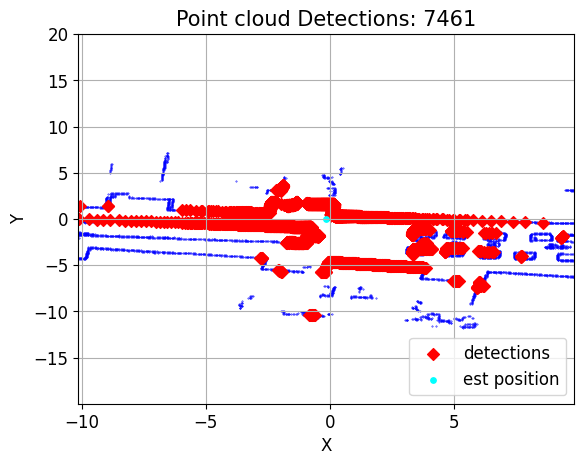

In [4]:
#initialize the test bench
test_bench = icp2DLocalizationTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.0,0.0])

test_bench.init_localization(
    est_start_heading_rad=np.deg2rad(0),
    est_start_pose_m=np.array([0.0,0.0]),
    show=True
)


In [5]:
test_bench.run()

100%|██████████| 1892/1892 [03:03<00:00, 10.34it/s]


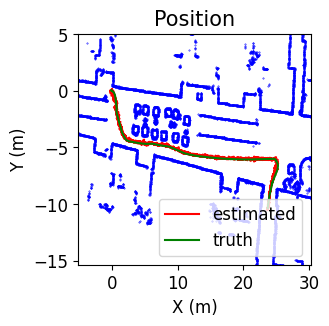

In [6]:
test_bench.plotter.plot_position_history_m(
    history_position_m=test_bench.history_position_m,
    history_position_m_gt=test_bench.history_position_m_gt,
    idx=0,
    ax=None,
    show=True
)

In [8]:
test_bench.analyze()

TypeError: Analyzer.compute_heading_state_estimate_errors() takes 2 positional arguments but 3 were given